In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
import plotly.express as px
from sklearn.impute import SimpleImputer, KNNImputer

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [3]:
# Machine learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# For classification tasks
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
# metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Load the Dataset

In [4]:
df = pd.read_csv('heart_disease_uci.csv')
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## EDA

### Explore each column

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [6]:
df.isnull().sum().sort_values(ascending=False)

ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
exang        55
thalch       55
chol         30
restecg       2
cp            0
dataset       0
id            0
age           0
sex           0
num           0
dtype: int64

In [7]:
df.shape

(920, 16)

In [8]:
# id columns
df['id'].min(), df['id'].max()

(1, 920)

In [9]:
# age column
df['age'].min(), df['age'].max()

(28, 77)

<Axes: xlabel='age', ylabel='Count'>

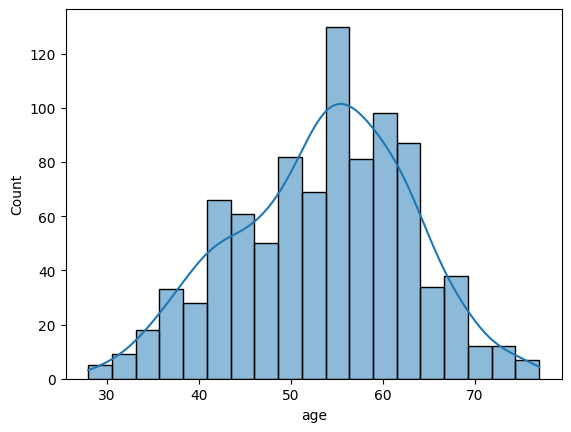

In [10]:
# draw a histplot to see the distribution of age column
sns.histplot(df['age'], kde=True)

Mean :  53.51086956521739
Median :  54.0
Mode :  54


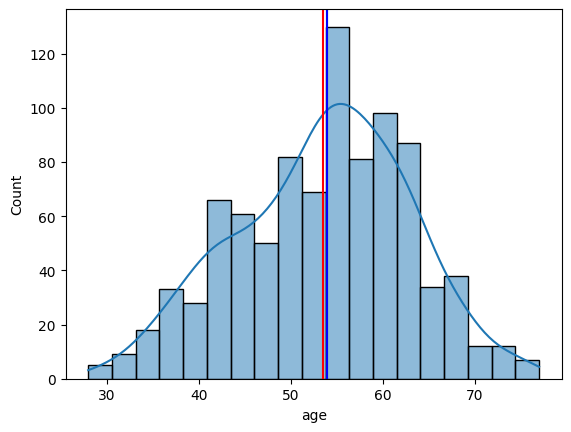

In [11]:
# Plot the mean, median, and mode of age column
sns.histplot(df['age'], kde=True)
plt.axvline(df['age'].mean(), color='red')
plt.axvline(df['age'].median(), color='green')
plt.axvline(df['age'].mode()[0], color='blue')

# Print the values 
print('Mean : ', df['age'].mean())
print('Median : ', df['age'].median())
print('Mode : ', df['age'].mode()[0])

In [12]:
# plot the histogram of age column using plotly and coloring this by sex
fig = px.histogram(data_frame=df, x='age', color='sex')
fig.show()

In [13]:
# find the values counts of age column
df['sex'].value_counts()

sex
Male      726
Female    194
Name: count, dtype: int64

In [14]:
# find the valuers counts of age column grouping by sex column
df.groupby('sex')['age'].value_counts()

sex     age
Female  54     15
        51     11
        62     10
        43      9
        48      9
               ..
Male    77      2
        28      1
        31      1
        33      1
        76      1
Name: count, Length: 91, dtype: int64

In [15]:
# Let's deal with dataset column
# find unique values in dataset column
df['dataset'].unique()

array(['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach'],
      dtype=object)

In [16]:
df['dataset'].value_counts()

dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

<Axes: xlabel='dataset', ylabel='count'>

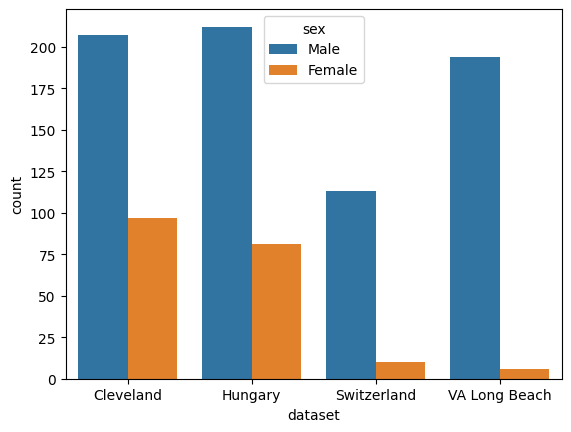

In [17]:
# plot the countplot of dataset column
sns.countplot(data=df, x='dataset', hue='sex')

In [18]:
# make a count using plotly

fig = px.bar(df, x='dataset', color='sex')
fig.show()

In [19]:
# make a plot of age column using plotly and coloring this by dataset column
fig = px.histogram(data_frame=df, x='age', color='dataset')
fig.show()

In [20]:
# print mean, medain and mode of age column group by datset column
print('Mean of the dataset : ',df.groupby('dataset')['age'].mean())
print('\nMedian of the dataset : ',df.groupby('dataset')['age'].median())
print('\nMode of the dataset : ',df.groupby('dataset')['age'].agg(pd.Series.mode))

Mean of the dataset :  dataset
Cleveland        54.351974
Hungary          47.894198
Switzerland      55.317073
VA Long Beach    59.350000
Name: age, dtype: float64

Median of the dataset :  dataset
Cleveland        55.5
Hungary          49.0
Switzerland      56.0
VA Long Beach    60.0
Name: age, dtype: float64

Mode of the dataset :  dataset
Cleveland              58
Hungary                54
Switzerland            61
VA Long Beach    [62, 63]
Name: age, dtype: object


## Lets explore CP column

In [21]:
df['cp'].value_counts()

cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

In [22]:
# draw the plot of age column grouped by cp column
fig = px.histogram(data_frame=df, x='age', color='cp')
fig.show()

## Let's trestbps

In [23]:
df['trestbps'].value_counts()

trestbps
120.0    131
130.0    115
140.0    102
110.0     59
150.0     56
        ... 
92.0       1
185.0      1
0.0        1
96.0       1
127.0      1
Name: count, Length: 61, dtype: int64

<Axes: xlabel='trestbps', ylabel='Count'>

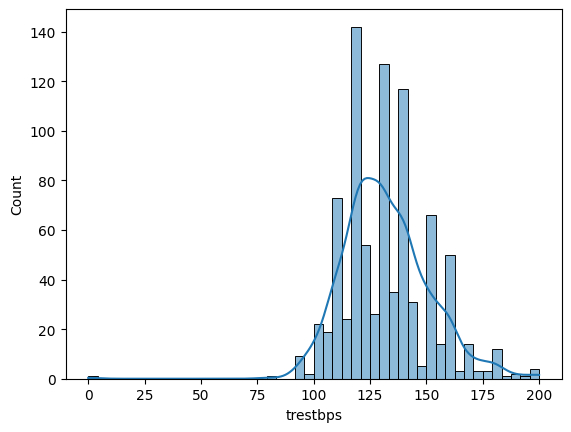

In [24]:
sns.histplot(df['trestbps'], kde=True)

In [25]:
df['trestbps'].isnull().sum()

np.int64(59)

In [26]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Create imputer
imputer = IterativeImputer(max_iter=10, random_state=42)

# Fit on column
imputer.fit(df[['trestbps']])

# Transform data
df['trestbps'] = imputer.transform(df[['trestbps']])

df['trestbps'].isnull().sum()

np.int64(0)

In [27]:
# Let's impute other columns with missing values
df.isnull().sum().sort_values(ascending=False)

ca          611
thal        486
slope       309
fbs          90
oldpeak      62
thalch       55
exang        55
chol         30
restecg       2
trestbps      0
cp            0
dataset       0
age           0
id            0
sex           0
num           0
dtype: int64

In [28]:
# check the datatype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  920 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [29]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Columns to impute
cols_to_impute = ['chol', 'thalch', 'oldpeak', 'ca']

# Create imputer
imputer2 = IterativeImputer(max_iter=10, random_state=42)

# Fit and transform together
df[cols_to_impute] = imputer2.fit_transform(df[cols_to_impute])

# Check missing values
print(df[cols_to_impute].isnull().sum())

chol       0
thalch     0
oldpeak    0
ca         0
dtype: int64


In [30]:
df.isnull().sum().sort_values(ascending=False)

thal        486
slope       309
fbs          90
exang        55
restecg       2
id            0
sex           0
age           0
chol          0
trestbps      0
cp            0
dataset       0
oldpeak       0
thalch        0
ca            0
num           0
dtype: int64

In [31]:
# Let's impute the missing values
from sklearn.impute import SimpleImputer

# Columns with missing values
cols_to_impute = ['thal', 'slope', 'fbs', 'exang', 'restecg']

# Create imputer
imputer3 = SimpleImputer(strategy='most_frequent')

# Fit and transform
df[cols_to_impute] = imputer3.fit_transform(df[cols_to_impute])

# Check missing values
print(df[cols_to_impute].isnull().sum())

thal       0
slope      0
fbs        0
exang      0
restecg    0
dtype: int64


In [32]:
df.isnull().sum()

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

## Deals with Outliers

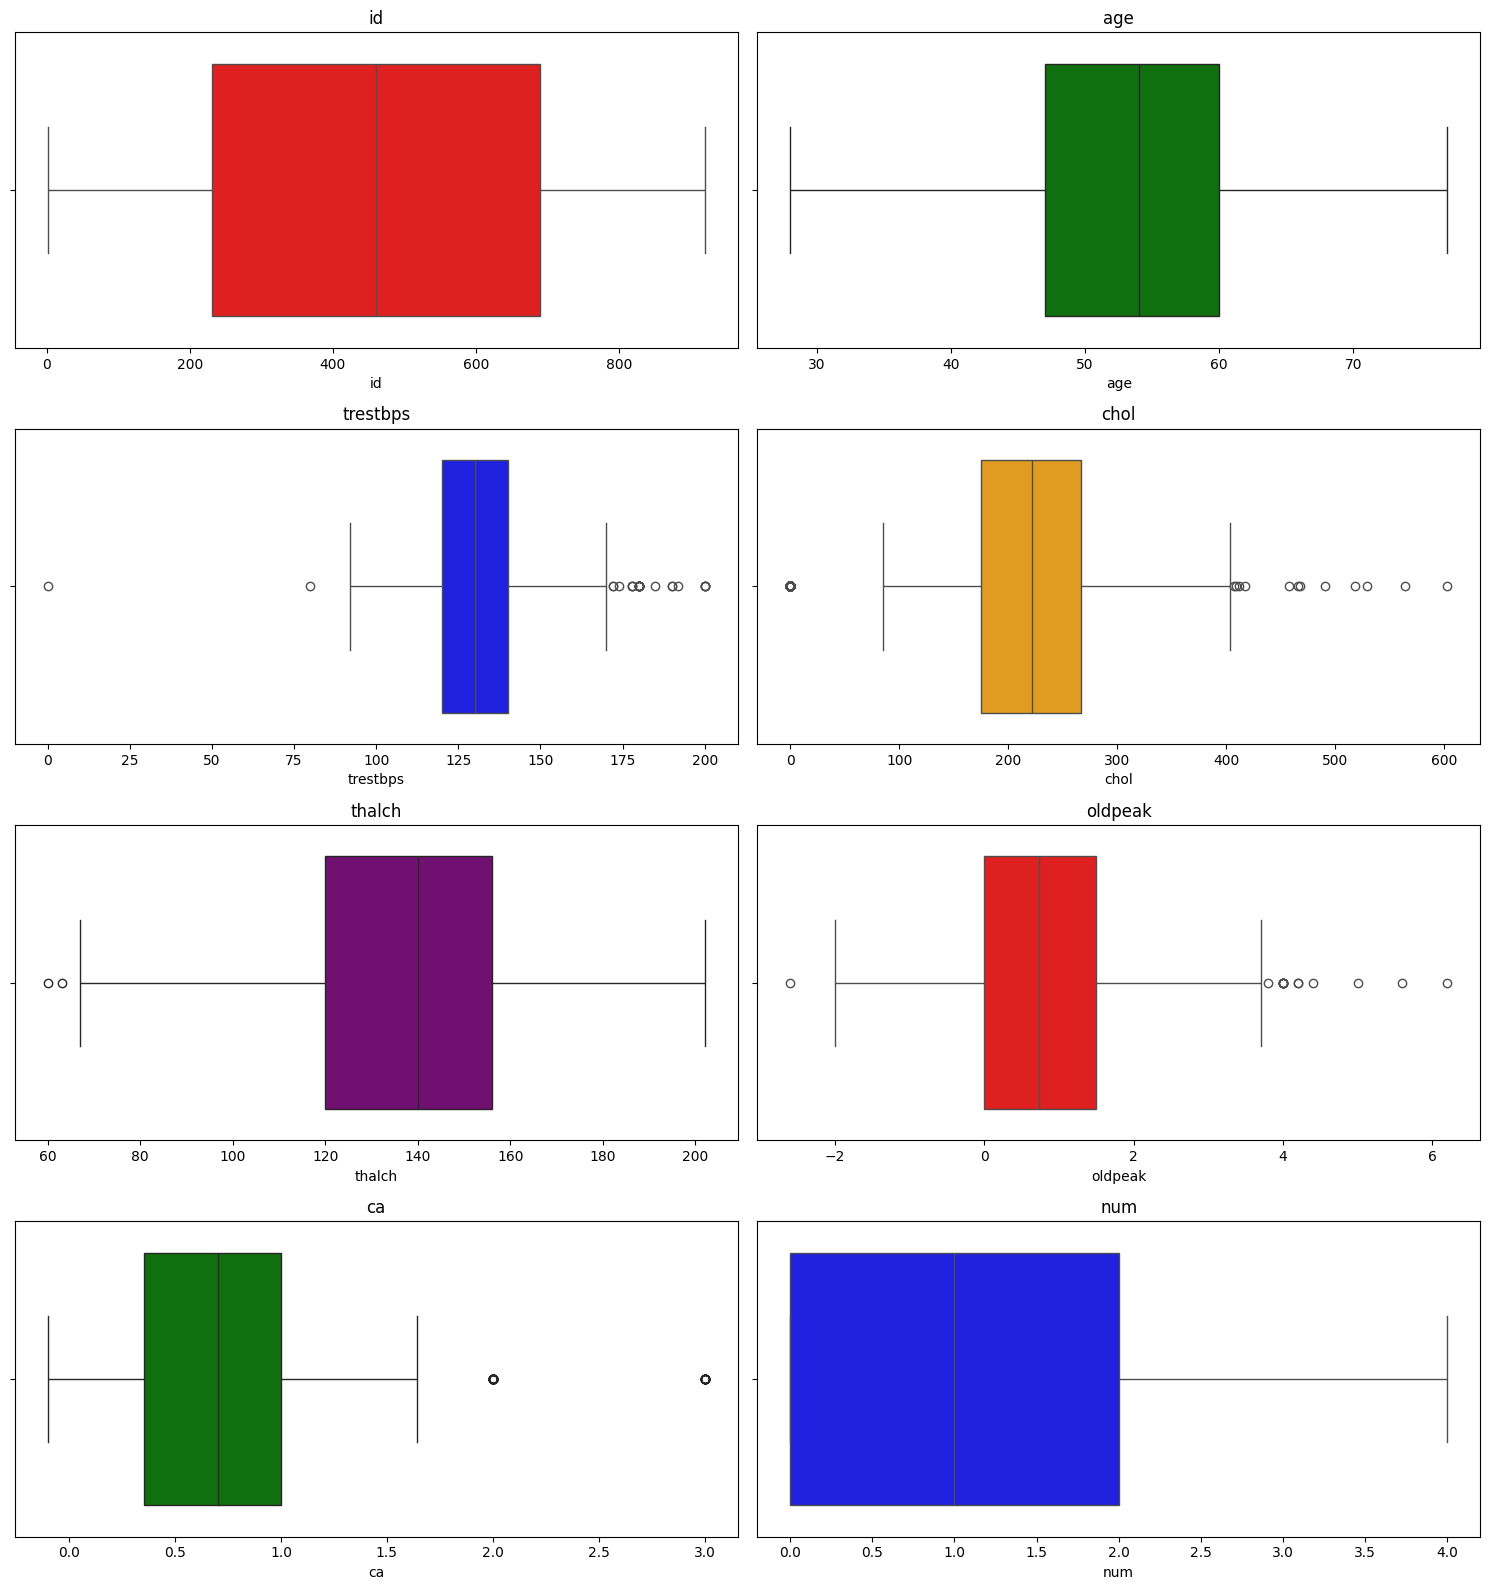

In [39]:
# create box plot for all numeric columns using for loop and subplot
import math

# Numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Colors
colors = ['red', 'green', 'blue', 'orange', 'purple']

# Number of columns in subplot grid
n_cols = 2

# Calculate required rows
n_rows = math.ceil(len(numeric_cols) / n_cols)

# Figure size
plt.figure(figsize=(15, n_rows * 4))

# Create boxplots
for i, col in enumerate(numeric_cols):
    
    plt.subplot(n_rows, n_cols, i + 1)
    
    sns.boxplot(x=df[col], color=colors[i % len(colors)])
    
    plt.title(col)

plt.tight_layout()
plt.show()

# Machine Learning

In [40]:
df['num'].value_counts()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

In [41]:
# split the data into x and y
X = df.drop('num',axis=1)
y = df['num']

# encode X data using seperate label encoder for all categorical columns and save 
label_encoder = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype == 'category':
        X[col] = label_encoder.fit_transform(X[col])
    else:
        pass
        
# Split the data
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## list all the models that you will use to predict the heart diseases
### 1.logistic regression
### 2. KNN
### 3. NB
### 4. SVM
### 5. Decision Tree
### 6. Random Forest
### 7. catboost
### 8. XGBoost
### 9. lightGBM
### 10.Adaboost

In [44]:
# import all models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
#from Lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [45]:
# create a function to train and evaluate all models and select the best hyperparameter
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# ==============================
# MODELS LIST
# ==============================

models = [

    ('Logistic Regression',
     LogisticRegression(max_iter=1000)),

    ('Decision Tree',
     DecisionTreeClassifier()),

    ('Random Forest',
     RandomForestClassifier()),

    ('Extra Trees',
     ExtraTreesClassifier()),

    ('Gradient Boosting',
     GradientBoostingClassifier()),

    ('AdaBoost',
     AdaBoostClassifier()),

    ('KNN',
     KNeighborsClassifier()),

    ('SVM',
     SVC()),

    ('Gaussian NB',
     GaussianNB()),

    ('XGBoost',
     XGBClassifier(
         use_label_encoder=False,
         eval_metric='logloss'
     )),

    ('CatBoost',
     CatBoostClassifier(
         verbose=False
     ))
]

# ==============================
# CATEGORICAL & NUMERICAL COLUMNS
# ==============================

categorical_cols = X_train.select_dtypes(
    include=['object', 'category']
).columns

numerical_cols = X_train.select_dtypes(
    include=['int64', 'float64']
).columns

# ==============================
# PREPROCESSOR
# ==============================

preprocessor = ColumnTransformer([

    ('num',
     SimpleImputer(strategy='mean'),
     numerical_cols),

    ('cat',
     Pipeline([
         ('imputer',
          SimpleImputer(strategy='most_frequent')),

         ('encoder',
          OneHotEncoder(handle_unknown='ignore'))
     ]),
     categorical_cols)
])

# ==============================
# VARIABLES
# ==============================

best_accuracy = 0
best_model = None

# ==============================
# TRAIN & EVALUATE
# ==============================

for name, model in models:

    # create pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # cross validation
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    mean_accuracy = scores.mean()

    # fit model
    pipeline.fit(X_train, y_train)

    # prediction
    y_pred = pipeline.predict(X_test)

    # accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # print results
    print("="*50)
    print("Model :", name)
    print("Cross Validation Accuracy :", mean_accuracy)
    print("Test Accuracy :", accuracy)
    print("="*50)
    print()

    # best model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = pipeline

# ==============================
# BEST MODEL
# ==============================

print("Best Model :")
print(best_model)

print()

print("Best Accuracy :", best_accuracy)

D:\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
D:\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_resu

Model : Logistic Regression
Cross Validation Accuracy : 0.5896396396396396
Test Accuracy : 0.5652173913043478

Model : Decision Tree
Cross Validation Accuracy : 0.571970950542379
Test Accuracy : 0.5543478260869565

Model : Random Forest
Cross Validation Accuracy : 0.641257584114727
Test Accuracy : 0.5815217391304348

Model : Extra Trees
Cross Validation Accuracy : 0.6140834712263283
Test Accuracy : 0.5815217391304348

Model : Gradient Boosting
Cross Validation Accuracy : 0.6099926457069315
Test Accuracy : 0.6195652173913043

Model : AdaBoost
Cross Validation Accuracy : 0.6331310902739474
Test Accuracy : 0.5706521739130435

Model : KNN
Cross Validation Accuracy : 0.6045964331678617
Test Accuracy : 0.5271739130434783

Model : SVM
Cross Validation Accuracy : 0.5950818165103879
Test Accuracy : 0.5597826086956522

Model : Gaussian NB
Cross Validation Accuracy : 0.5448336091193233
Test Accuracy : 0.5271739130434783



C:\Users\2005a\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [16:16:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\2005a\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [16:16:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\2005a\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [16:16:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\2005a\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [16:16:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.

Model : XGBoost
Cross Validation Accuracy : 0.6235888950174664
Test Accuracy : 0.6467391304347826

Model : CatBoost
Cross Validation Accuracy : 0.6209045780474352
Test Accuracy : 0.625

Best Model :
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', SimpleImputer(),
                                                  Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))...
                               feature_types=

## Save the model

In [46]:
import pickle
pickle.dump(best_model, open('Heart_Disease_model.pkl', 'wb'))